# Generating MNIST with an RNN / GRU / LSTM in PyTorch

This notebook is a **Jupyter reimplementation** of the experiment in
[`nabla0001/mnist.rnn`](https://github.com/nabla0001/mnist.rnn):

- flatten each 28×28 MNIST image into a sequence of 784 pixels,
- train a recurrent model with **teacher forcing** to predict the next pixel,
- give the trained model only the first part of an unseen digit,
- generate the remaining pixels autoregressively.

The original repository uses a **GRU with 128 hidden units**.  
For teaching, this notebook keeps the same task and lets you switch between:

```python
MODEL_TYPE = "RNN"   # vanilla RNN
MODEL_TYPE = "GRU"   # original repo architecture
MODEL_TYPE = "LSTM"  # LSTM comparison
```

This makes it easy to compare all three models on exactly the same image-generation task.


## 1. Setup

If needed, uncomment the installation line and run it once.

The notebook works on CUDA, Apple MPS, or CPU.


In [1]:
# Uncomment if the packages are not installed:
# %pip install torch torchvision matplotlib tqdm

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import MNIST
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.4.1+cu124
Device: cuda


## 2. Hyperparameters

To reproduce the original experiment most closely, use `MODEL_TYPE = "GRU"` and
`HIDDEN_SIZE = 128`.

For a classroom demo, start with 3–5 epochs. For a longer experiment, increase
`NUM_EPOCHS` toward 50.


In [11]:
MODEL_TYPE = "RNN"       # "RNN", "GRU", or "LSTM"
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.0

BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 5            # original repo trains much longer
BINARIZE = True

# Number of real pixels shown before the network must finish the image.
N_GIVEN_PIXELS = 500


## 3. Turn MNIST images into pixel sequences

An MNIST image has shape `28 × 28`.

We flatten it row-by-row:

Training uses the shifted next-pixel prediction problem:


In [12]:
class MNISTPixelSequence(Dataset):
    def __init__(self, root="data", train=True, binarize=True):
        transform_steps = [transforms.ToTensor()]
        if binarize:
            transform_steps.append(
                transforms.Lambda(lambda x: (x > 0.1).float())
            )

        self.dataset = MNIST(
            root=root,
            train=train,
            download=True,
            transform=transforms.Compose(transform_steps),
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]

        # [1, 28, 28] -> [784, 1]
        pixels = image.reshape(-1, 1)

        inputs = pixels[:-1]   # pixels 1 ... 783
        targets = pixels[1:]   # pixels 2 ... 784

        return inputs, targets, label


full_train = MNISTPixelSequence(train=True, binarize=BINARIZE)
test_dataset = MNISTPixelSequence(train=False, binarize=BINARIZE)

train_size = 55_000
val_size = len(full_train) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train, [train_size, val_size], generator=generator
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

x, y, labels = next(iter(train_loader))
print("input :", x.shape)
print("target:", y.shape)
print("labels:", labels.shape)


input : torch.Size([128, 783, 1])
target: torch.Size([128, 783, 1])
labels: torch.Size([128])


## 4. Visualize the sequence interpretation

The recurrent network never receives a 2D image. It only sees a sequence of scalar pixel values.


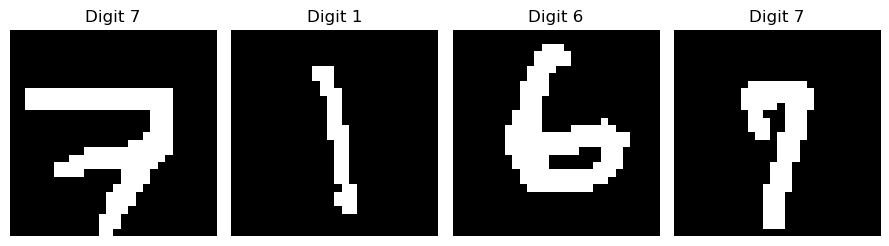

In [13]:
inputs, targets, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(9, 2.5))
for i, ax in enumerate(axes):
    # Reconstruct the full 784-pixel image:
    full_pixels = torch.cat([inputs[i, :1], targets[i]], dim=0)
    ax.imshow(full_pixels.reshape(28, 28), cmap="gray")
    ax.set_title(f"Digit {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Recurrent image generator

The output at every time step is a probability in `[0,1]` for the next pixel.

The only architectural difference between the experiments is the recurrent cell:
`nn.RNN`, `nn.GRU`, or `nn.LSTM`.


In [14]:
class PixelRNN(nn.Module):
    def __init__(
        self,
        model_type="GRU",
        hidden_size=128,
        num_layers=1,
        dropout=0.0,
    ):
        super().__init__()

        model_type = model_type.upper()
        self.model_type = model_type

        # PyTorch only applies recurrent dropout between layers.
        recurrent_dropout = dropout if num_layers > 1 else 0.0

        kwargs = dict(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=recurrent_dropout,
            batch_first=True,
        )

        if model_type == "RNN":
            self.rnn = nn.RNN(**kwargs)
        elif model_type == "GRU":
            self.rnn = nn.GRU(**kwargs)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(**kwargs)
        else:
            raise ValueError("MODEL_TYPE must be 'RNN', 'GRU', or 'LSTM'")

        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x, hidden=None):
        features, hidden = self.rnn(x, hidden)
        logits = self.output_layer(features)
        probabilities = torch.sigmoid(logits)
        return probabilities, hidden

    @torch.no_grad()
    def generate(self, prefix, n_steps, stochastic=False):
        """Generate n_steps after consuming a real pixel prefix.

        prefix shape: [batch, observed_steps, 1]
        returns:      [batch, n_steps]
        """
        self.eval()

        predictions, hidden = self(prefix)

        # The final teacher-forced output predicts the first unseen pixel.
        next_pixel = predictions[:, -1:, :]
        generated = []

        for _ in range(n_steps):
            if stochastic:
                emitted = torch.bernoulli(next_pixel)
            else:
                emitted = next_pixel

            generated.append(emitted[:, 0, 0])

            # Feed the generated pixel back into the recurrent model.
            next_pixel, hidden = self(emitted, hidden)

        return torch.stack(generated, dim=1)


model = PixelRNN(
    model_type=MODEL_TYPE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))


PixelRNN(
  (rnn): RNN(1, 128, batch_first=True)
  (output_layer): Linear(in_features=128, out_features=1, bias=True)
)
Parameters: 16897


## 6. Teacher-forcing training

During training the network receives the **true previous pixel** at every step.

This is fast and stable, but it creates a train/test mismatch: during generation,
the model must feed its own prediction back into itself.


In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[10, 20], gamma=0.1
)


def evaluate(model, loader, max_batches=10):
    model.eval()
    losses = []

    with torch.no_grad():
        for batch_idx, (inputs, targets, _) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs, _ = model(inputs)
            loss = criterion(outputs, targets)
            losses.append(loss.item())

    return float(np.mean(losses))


history = {"train": [], "val": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}",
        leave=False,
    )

    for inputs, targets, _ in progress:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs, _ = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()

    train_loss = running_loss / len(train_loader)
    val_loss = evaluate(model, val_loader, max_batches=10)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"train={train_loss:.4f} | val={val_loss:.4f}"
    )


Epoch 1/5:   0%|          | 0/430 [00:00<?, ?it/s]

Epoch 01 | train=0.0740 | val=0.0508


Epoch 2/5:   0%|          | 0/430 [00:00<?, ?it/s]

Epoch 02 | train=0.0440 | val=0.0373


Epoch 3/5:   0%|          | 0/430 [00:00<?, ?it/s]

Epoch 03 | train=0.0348 | val=0.0336


Epoch 4/5:   0%|          | 0/430 [00:00<?, ?it/s]

Epoch 04 | train=0.0328 | val=0.0329


Epoch 5/5:   0%|          | 0/430 [00:00<?, ?it/s]

Epoch 05 | train=0.0318 | val=0.0315


## 7. Plot training curves

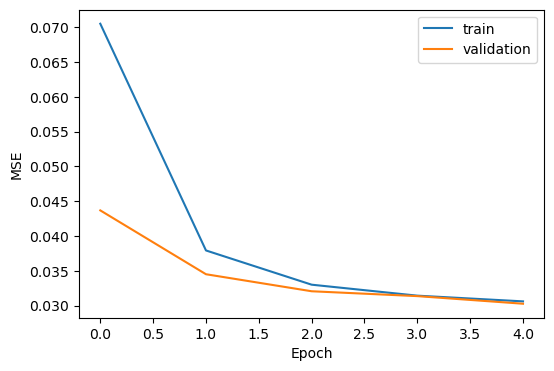

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()


## 8. Complete partially observed MNIST digits

We reveal the first `N_GIVEN_PIXELS` pixels and let the model generate the rest.

For `N_GIVEN_PIXELS = 500`, the model sees roughly the upper 18 rows and must
complete the bottom of the digit.


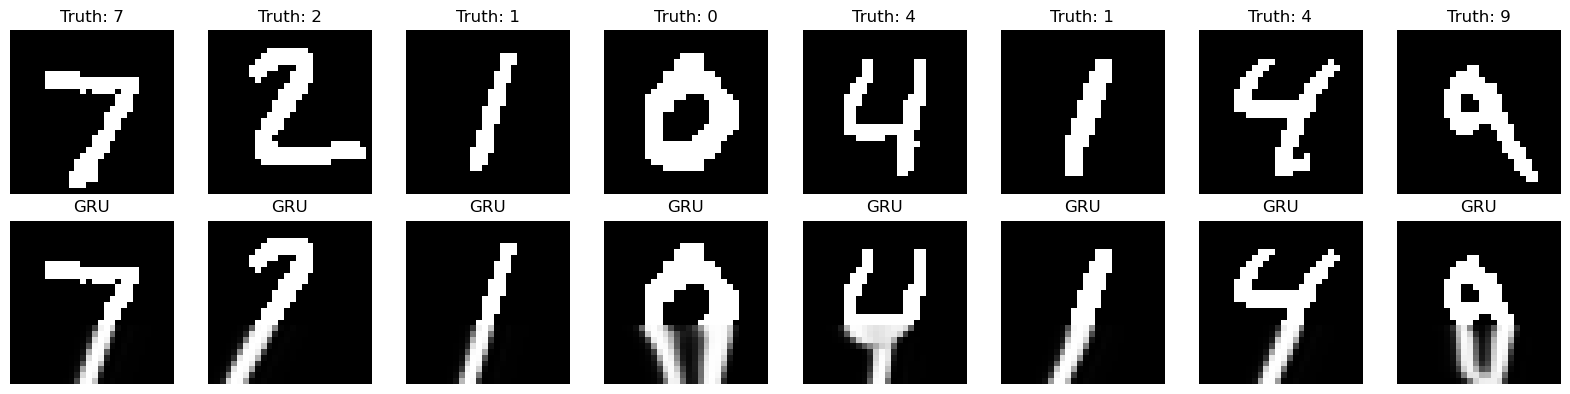

In [8]:
@torch.no_grad()
def make_completions(model, loader, n_given=500, n_examples=8, stochastic=False):
    model.eval()

    inputs, targets, labels = next(iter(loader))

    # Reconstruct [batch, 784, 1].
    full = torch.cat([inputs[:, :1], targets], dim=1)

    full = full[:n_examples]
    labels = labels[:n_examples]

    prefix = full[:, :n_given].to(device)
    n_missing = 784 - n_given

    generated = model.generate(
        prefix,
        n_steps=n_missing,
        stochastic=stochastic,
    ).cpu()

    completed = torch.cat(
        [prefix.cpu().squeeze(-1), generated],
        dim=1,
    )

    return full.squeeze(-1), completed, labels


ground_truth, completed, labels = make_completions(
    model,
    test_loader,
    n_given=N_GIVEN_PIXELS,
    n_examples=8,
    stochastic=False,
)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(ground_truth[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Truth: {labels[i].item()}")
    axes[0, i].axis("off")

    axes[1, i].imshow(completed[i].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(MODEL_TYPE)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## 9. Show exactly what was given vs generated

The red horizontal boundary is not needed for the model; it is only useful conceptually.
Because pixels are flattened row-by-row, `500 // 28 ≈ 17.9` rows are observed.


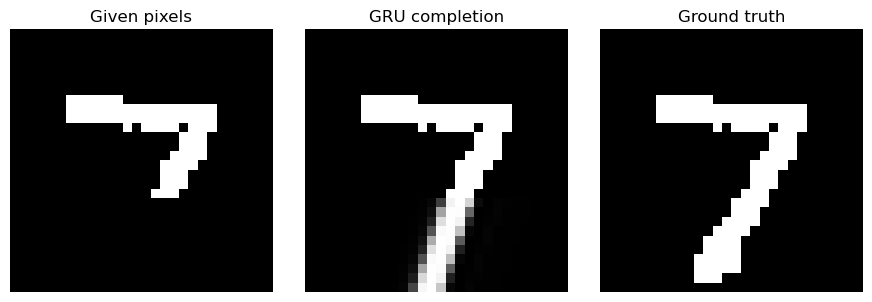

In [9]:
example = 0

prefix_only = torch.zeros(784)
prefix_only[:N_GIVEN_PIXELS] = ground_truth[example, :N_GIVEN_PIXELS]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(prefix_only.reshape(28, 28), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Given pixels")
axes[0].axis("off")

axes[1].imshow(completed[example].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"{MODEL_TYPE} completion")
axes[1].axis("off")

axes[2].imshow(ground_truth[example].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Ground truth")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 10. Save / load the trained model


In [10]:
checkpoint_name = f"mnist_{MODEL_TYPE.lower()}_{HIDDEN_SIZE}.pt"

torch.save(
    {
        "model_type": MODEL_TYPE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "state_dict": model.state_dict(),
    },
    checkpoint_name,
)

print("Saved:", checkpoint_name)


Saved: mnist_gru_128.pt
